 ## preparation of the decomposed automaton

In [217]:
# generate n chains of length m, where n and m are given by the user, default n = 5, m = 10
# fix some order of the chains
# add dependencies on the edges such that the edge of one chain depends on the states of later chains (not the previous ones in the fixed order)
# the number of states on which a given edge depends is chosen uniformly from {0,1, 2, 3}..if there are multiple states, they need to be from different chains.

import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random

def gen_chains(n=5, m=10):
    chains = defaultdict(list)

    for i in range(n):
        G = nx.Graph()
        nodes = [j for j in range(m)]
        edges = list(zip(nodes[:-1], nodes[1:]))

        G.add_edges_from(edges)
        chains[i] = G

    return chains

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:
                num_deps = random.randint(0, 3)
                
                if num_deps > 0:
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []
                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})
                    
                    G.edges[edge]['enabling'] = enabling_conditions
    
    return chains

chains = add_enabling(gen_chains())

In [218]:
print(chains[0].edges[(1,2)])

{}


In [219]:
for chain_id in range(len(chains)):
    print(f"\nChain {chain_id}:")
    G = chains[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")


Chain 0:
Edge 0 -> 1: {'enabling': [{'automata_id': 4, 'node_id': 8}]}
Edge 1 -> 2: {}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {}
Edge 6 -> 7: {'enabling': [{'automata_id': 2, 'node_id': 7}, {'automata_id': 1, 'node_id': 7}, {'automata_id': 3, 'node_id': 3}]}
Edge 7 -> 8: {}
Edge 8 -> 9: {'enabling': [{'automata_id': 3, 'node_id': 6}, {'automata_id': 4, 'node_id': 5}]}

Chain 1:
Edge 0 -> 1: {}
Edge 1 -> 2: {'enabling': [{'automata_id': 3, 'node_id': 3}]}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {'enabling': [{'automata_id': 2, 'node_id': 2}, {'automata_id': 4, 'node_id': 0}]}
Edge 6 -> 7: {}
Edge 7 -> 8: {'enabling': [{'automata_id': 2, 'node_id': 6}, {'automata_id': 3, 'node_id': 5}]}
Edge 8 -> 9: {}

Chain 2:
Edge 0 -> 1: {'enabling': [{'automata_id': 4, 'node_id': 6}]}
Edge 1 -> 2: {'enabling': [{'automata_id': 4, 'node_id': 1}, {'automata_id': 3, 'node_id': 8}]}
Edge 2 -> 3: {}
Edge 3 -> 4: {}
Edge 4 -> 5: {}
Edge 5 -> 6: {}
Edge 6 -> 7: {

In [220]:
chains[0].nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9))

## creation of 1 sample problem

In [221]:
# for the fixed order of chains, create a vector of states for each chain. states in different chains are chosen randomly.
# choose 1 chain as the target chain
# choose a random target state in the target chain
# the result is sample = {"input": vector of states, "target": target state, "target chain": target chain}

In [222]:
from itertools import product
def get_vectors(chains):
    states_per_chain = []
    for chain_id in range(len(chains)):
        states_per_chain.append(list(chains[chain_id].nodes()))
    
    return list(product(*states_per_chain))

vecs = get_vectors(chains)

In [223]:
from tqdm import tqdm
id_2_vec = {}
vec_2_id = {}
for i, comb in tqdm(enumerate(vecs)):
    id_2_vec[i] = comb
    vec_2_id[comb] = i

100000it [00:00, 4073484.45it/s]


In [224]:
def get_sample(vector, chains):
    num_chains = len(chains)
    num_states = len(chains[0].nodes())
    
    target_chain = random.randint(0, num_chains-1)

    target_state = random.randint(0, num_states-1)
    
    return {
        'input': list(vector),
        'target_state': target_state,
        'target_chain': target_chain
    }

In [225]:
sample = get_sample(vecs[12223], chains)
sample

{'input': [1, 2, 2, 2, 3], 'target_state': 5, 'target_chain': 3}

## implementation of the solver

In [226]:
sample = {'input': [1, 2, 2, 2, 3], 'target_state': 7, 'target_chain': 0}

In [227]:
steps_log = []
shortest_paths_log = []

def get_rule(chains, target_chain, cur_node, next_node):
    cur_rule = chains[target_chain].get_edge_data(cur_node, next_node)
    steps_log.append((target_chain, cur_node, next_node, cur_rule))
    return cur_rule

def get_shortest_path(chains, target_chain, current_state, target_state):
    shortest_path = nx.shortest_path(chains[target_chain],current_state[target_chain], target_state)
    shortest_paths_log.append((target_chain,shortest_path))
    return shortest_path

def solve(sample, chains, path=[]):
    target_chain = sample["target_chain"]
    target_state = sample["target_state"]
    current_state = list(sample["input"])
    shortest_paths = get_shortest_path(chains, target_chain, current_state, target_state)
    for i, cur_node in enumerate(shortest_paths):
        if i < len(shortest_paths)-1:
            next_node = shortest_paths[i+1]
            cur_rule = get_rule(chains, target_chain, cur_node, next_node)
            if cur_rule == {}:
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node

                continue
            else:
                for rules in cur_rule["enabling"]:
                    new_sample = {}
                    new_sample['input'] = current_state
                    new_sample["target_state"] = rules["node_id"]
                    new_sample['target_chain'] = rules["automata_id"]
                    path, current_state = solve(new_sample, chains, path)
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node
                # after each dependency state is resolved, cross the edge and append it to the path and change the current state
                # after the shortest path to the target state if traversed, return the path and the current state
    return path, current_state

    # for the target chain, find all shortest paths from the current state to the target state
    # take the first path and try to traverse it. ie iterate over the edges and do the following:
    # # if the edge is not dependent on other states:
    # # # cross the edge, i.e. change the current state for the target chain to get one more step closer to the target state
    # # # path.append(edge)
    # # else get the dependency states, depenendet = edge['enabling']
    # # for each dependency state, do the following:
    # # # new_sample = {}
    # # # new_sample['input_states'] = current_state
    # # # new_sample["target"] = dependency_state
    # # # new_sample['target chain'] = chain of the dependency state
    # # # path, current_state = solve(new_sample,path)
    # # after each dependency state is resolved, cross the edge and append it to the path and change the current state
    # after the shortest path to the target state if traversed, return the path and the current state

In [228]:
solver_path = solve(sample, chains)
solver_path, len(solver_path[0])

(([{'automata_id': 0, 'state_change': (1, 2)},
   {'automata_id': 0, 'state_change': (2, 3)},
   {'automata_id': 0, 'state_change': (3, 4)},
   {'automata_id': 0, 'state_change': (4, 5)},
   {'automata_id': 0, 'state_change': (5, 6)},
   {'automata_id': 2, 'state_change': (2, 3)},
   {'automata_id': 2, 'state_change': (3, 4)},
   {'automata_id': 2, 'state_change': (4, 5)},
   {'automata_id': 2, 'state_change': (5, 6)},
   {'automata_id': 2, 'state_change': (6, 7)},
   {'automata_id': 1, 'state_change': (2, 3)},
   {'automata_id': 1, 'state_change': (3, 4)},
   {'automata_id': 1, 'state_change': (4, 5)},
   {'automata_id': 2, 'state_change': (7, 6)},
   {'automata_id': 2, 'state_change': (6, 5)},
   {'automata_id': 2, 'state_change': (5, 4)},
   {'automata_id': 2, 'state_change': (4, 3)},
   {'automata_id': 2, 'state_change': (3, 2)},
   {'automata_id': 4, 'state_change': (3, 2)},
   {'automata_id': 4, 'state_change': (2, 1)},
   {'automata_id': 4, 'state_change': (1, 0)},
   {'automata

In [229]:
shortest_paths = {}

for step in solver_path[0]:
    shortest_paths[step['automata_id']] = nx.shortest_path(chains[step['automata_id']],
                                                           step['state_change'][1], )
    print(step)

{'automata_id': 0, 'state_change': (1, 2)}
{'automata_id': 0, 'state_change': (2, 3)}
{'automata_id': 0, 'state_change': (3, 4)}
{'automata_id': 0, 'state_change': (4, 5)}
{'automata_id': 0, 'state_change': (5, 6)}
{'automata_id': 2, 'state_change': (2, 3)}
{'automata_id': 2, 'state_change': (3, 4)}
{'automata_id': 2, 'state_change': (4, 5)}
{'automata_id': 2, 'state_change': (5, 6)}
{'automata_id': 2, 'state_change': (6, 7)}
{'automata_id': 1, 'state_change': (2, 3)}
{'automata_id': 1, 'state_change': (3, 4)}
{'automata_id': 1, 'state_change': (4, 5)}
{'automata_id': 2, 'state_change': (7, 6)}
{'automata_id': 2, 'state_change': (6, 5)}
{'automata_id': 2, 'state_change': (5, 4)}
{'automata_id': 2, 'state_change': (4, 3)}
{'automata_id': 2, 'state_change': (3, 2)}
{'automata_id': 4, 'state_change': (3, 2)}
{'automata_id': 4, 'state_change': (2, 1)}
{'automata_id': 4, 'state_change': (1, 0)}
{'automata_id': 1, 'state_change': (5, 6)}
{'automata_id': 1, 'state_change': (6, 7)}
{'automata_

In [230]:
steps_log, len(steps_log)

([(0, 1, 2, {}),
  (0, 2, 3, {}),
  (0, 3, 4, {}),
  (0, 4, 5, {}),
  (0, 5, 6, {}),
  (0,
   6,
   7,
   {'enabling': [{'automata_id': 2, 'node_id': 7},
     {'automata_id': 1, 'node_id': 7},
     {'automata_id': 3, 'node_id': 3}]}),
  (2, 2, 3, {}),
  (2, 3, 4, {}),
  (2, 4, 5, {}),
  (2, 5, 6, {}),
  (2, 6, 7, {}),
  (1, 2, 3, {}),
  (1, 3, 4, {}),
  (1, 4, 5, {}),
  (1,
   5,
   6,
   {'enabling': [{'automata_id': 2, 'node_id': 2},
     {'automata_id': 4, 'node_id': 0}]}),
  (2, 7, 6, {}),
  (2, 6, 5, {}),
  (2, 5, 4, {}),
  (2, 4, 3, {}),
  (2, 3, 2, {}),
  (4, 3, 2, {}),
  (4, 2, 1, {}),
  (4, 1, 0, {}),
  (1, 6, 7, {}),
  (3, 2, 3, {})],
 25)

In [231]:
def group_automata(data):
    changes, finals = data
    result = []
    
    for change in changes:
        if result and result[-1]['automata_id'] == change['automata_id']:
            result[-1]['state_change'].append(change['state_change'])
        else:
            result.append({'automata_id': change['automata_id'], 
                         'state_change': [change['state_change']]})
            
    return (result, finals)

In [232]:
def group_rules(data):
    result = []
    
    for rule in data:
        if result and result[-1]['automata_id'] == rule[0]:
            result[-1]['state_change'].append(((rule[1], rule[2]), rule[3]))
        else:
            result.append({'automata_id': rule[0],  
                         'state_change': [((rule[1], rule[2]), rule[3])]})
            
    return result

In [233]:
rules_grp = group_rules(steps_log)
rules_grp, len(rules_grp)

([{'automata_id': 0,
   'state_change': [((1, 2), {}),
    ((2, 3), {}),
    ((3, 4), {}),
    ((4, 5), {}),
    ((5, 6), {}),
    ((6, 7),
     {'enabling': [{'automata_id': 2, 'node_id': 7},
       {'automata_id': 1, 'node_id': 7},
       {'automata_id': 3, 'node_id': 3}]})]},
  {'automata_id': 2,
   'state_change': [((2, 3), {}),
    ((3, 4), {}),
    ((4, 5), {}),
    ((5, 6), {}),
    ((6, 7), {})]},
  {'automata_id': 1,
   'state_change': [((2, 3), {}),
    ((3, 4), {}),
    ((4, 5), {}),
    ((5, 6),
     {'enabling': [{'automata_id': 2, 'node_id': 2},
       {'automata_id': 4, 'node_id': 0}]})]},
  {'automata_id': 2,
   'state_change': [((7, 6), {}),
    ((6, 5), {}),
    ((5, 4), {}),
    ((4, 3), {}),
    ((3, 2), {})]},
  {'automata_id': 4,
   'state_change': [((3, 2), {}), ((2, 1), {}), ((1, 0), {})]},
  {'automata_id': 1, 'state_change': [((6, 7), {})]},
  {'automata_id': 3, 'state_change': [((2, 3), {})]}],
 7)

In [234]:
used_rules = []
for x in rules_grp:
    for y in x['state_change']:
        if y[1] != {}:
            used_rules.append(y)
for rule in used_rules:
    print(rule)
len(used_rules)

((6, 7), {'enabling': [{'automata_id': 2, 'node_id': 7}, {'automata_id': 1, 'node_id': 7}, {'automata_id': 3, 'node_id': 3}]})
((5, 6), {'enabling': [{'automata_id': 2, 'node_id': 2}, {'automata_id': 4, 'node_id': 0}]})


2

In [235]:
path_grp = group_automata(solver_path)
path_grp, len(path_grp[0])

(([{'automata_id': 0,
    'state_change': [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]},
   {'automata_id': 2,
    'state_change': [(2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]},
   {'automata_id': 1, 'state_change': [(2, 3), (3, 4), (4, 5)]},
   {'automata_id': 2,
    'state_change': [(7, 6), (6, 5), (5, 4), (4, 3), (3, 2)]},
   {'automata_id': 4, 'state_change': [(3, 2), (2, 1), (1, 0)]},
   {'automata_id': 1, 'state_change': [(5, 6), (6, 7)]},
   {'automata_id': 3, 'state_change': [(2, 3)]},
   {'automata_id': 0, 'state_change': [(6, 7)]}],
  [7, 7, 2, 3, 0]),
 8)

***Prepare data for visualization***

In [236]:
#TODO faulty logic, needs rethinking

# Combine path and rule groups
combined_paths = [step for step in rules_grp]
idx = 0
for path_tmp, rule in zip(path_grp[0], rules_grp):

    if path_tmp['automata_id'] != rule['automata_id']:

        tmp = []
        for item in path_tmp['state_change']:
            tmp.append((item, {}))
        combined_paths.insert(idx, {'automata_id': path_tmp['automata_id'], 'state_change': tmp})

    idx += 1

combined_paths, len(combined_paths)

([{'automata_id': 0,
   'state_change': [((1, 2), {}),
    ((2, 3), {}),
    ((3, 4), {}),
    ((4, 5), {}),
    ((5, 6), {}),
    ((6, 7),
     {'enabling': [{'automata_id': 2, 'node_id': 7},
       {'automata_id': 1, 'node_id': 7},
       {'automata_id': 3, 'node_id': 3}]})]},
  {'automata_id': 2,
   'state_change': [((2, 3), {}),
    ((3, 4), {}),
    ((4, 5), {}),
    ((5, 6), {}),
    ((6, 7), {})]},
  {'automata_id': 1,
   'state_change': [((2, 3), {}),
    ((3, 4), {}),
    ((4, 5), {}),
    ((5, 6),
     {'enabling': [{'automata_id': 2, 'node_id': 2},
       {'automata_id': 4, 'node_id': 0}]})]},
  {'automata_id': 2,
   'state_change': [((7, 6), {}),
    ((6, 5), {}),
    ((5, 4), {}),
    ((4, 3), {}),
    ((3, 2), {})]},
  {'automata_id': 4,
   'state_change': [((3, 2), {}), ((2, 1), {}), ((1, 0), {})]},
  {'automata_id': 1, 'state_change': [((6, 7), {})]},
  {'automata_id': 3, 'state_change': [((2, 3), {})]}],
 7)

In [245]:
# delete row in shortest_paths_log that contains only one instance
shortest_paths_log = [x for x in shortest_paths_log if len(x[1]) > 1]
shortest_paths_log, len(shortest_paths_log)

([(0, [1, 2, 3, 4, 5, 6, 7]),
  (2, [2, 3, 4, 5, 6, 7]),
  (1, [2, 3, 4, 5, 6, 7]),
  (2, [7, 6, 5, 4, 3, 2]),
  (4, [3, 2, 1, 0]),
  (3, [2, 3])],
 6)

In [252]:
full_path = []
previous_states = [state for state in sample['input']]
states = [state for state in sample['input']]

last_automata_id = path_grp[0][0]['automata_id']
last_next_state = path_grp[0][0]['state_change'][0][1]
shortest_paths_log_tmp = [(item[0], [i for i in item[1]]) for item in shortest_paths_log]

for rules in path_grp[0]:

    for item in shortest_paths_log_tmp:
        if item[0] == rules['automata_id'] and item[1] != []:
            current_shortest_path = item[1][:len(rules['state_change'])+1]
            item[1][:len(rules['state_change'])+1] = []
            break

    for i, state_change in enumerate(rules['state_change']):
        # Update state of last automata, needed when switching from one
        states[last_automata_id] = last_next_state
        states[rules['automata_id']] = state_change[0]
            
        full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': [state for state in states],
                            'next_state': state_change[1],
                            'shortest_path': current_shortest_path[i:],
                            'edge': state_change,})
        
        last_automata_id = rules['automata_id']
        last_next_state = state_change[1]

# Last step
full_path.append({'target': {'automata_id': sample['target_chain'], 'state': sample['target_state']},
                            'automata_id': rules['automata_id'],
                            'states': path_grp[1],
                            'next_state': state_change[1],})

full_path, len(full_path)

([{'target': {'automata_id': 0, 'state': 7},
   'automata_id': 0,
   'states': [1, 2, 2, 2, 3],
   'next_state': 2,
   'shortest_path': [1, 2, 3, 4, 5, 6],
   'edge': (1, 2)},
  {'target': {'automata_id': 0, 'state': 7},
   'automata_id': 0,
   'states': [2, 2, 2, 2, 3],
   'next_state': 3,
   'shortest_path': [2, 3, 4, 5, 6],
   'edge': (2, 3)},
  {'target': {'automata_id': 0, 'state': 7},
   'automata_id': 0,
   'states': [3, 2, 2, 2, 3],
   'next_state': 4,
   'shortest_path': [3, 4, 5, 6],
   'edge': (3, 4)},
  {'target': {'automata_id': 0, 'state': 7},
   'automata_id': 0,
   'states': [4, 2, 2, 2, 3],
   'next_state': 5,
   'shortest_path': [4, 5, 6],
   'edge': (4, 5)},
  {'target': {'automata_id': 0, 'state': 7},
   'automata_id': 0,
   'states': [5, 2, 2, 2, 3],
   'next_state': 6,
   'shortest_path': [5, 6],
   'edge': (5, 6)},
  {'target': {'automata_id': 0, 'state': 7},
   'automata_id': 2,
   'states': [6, 2, 2, 2, 3],
   'next_state': 3,
   'shortest_path': [2, 3, 4, 5, 6

**Visualization**

/home/jan/miniconda3/envs/sos/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


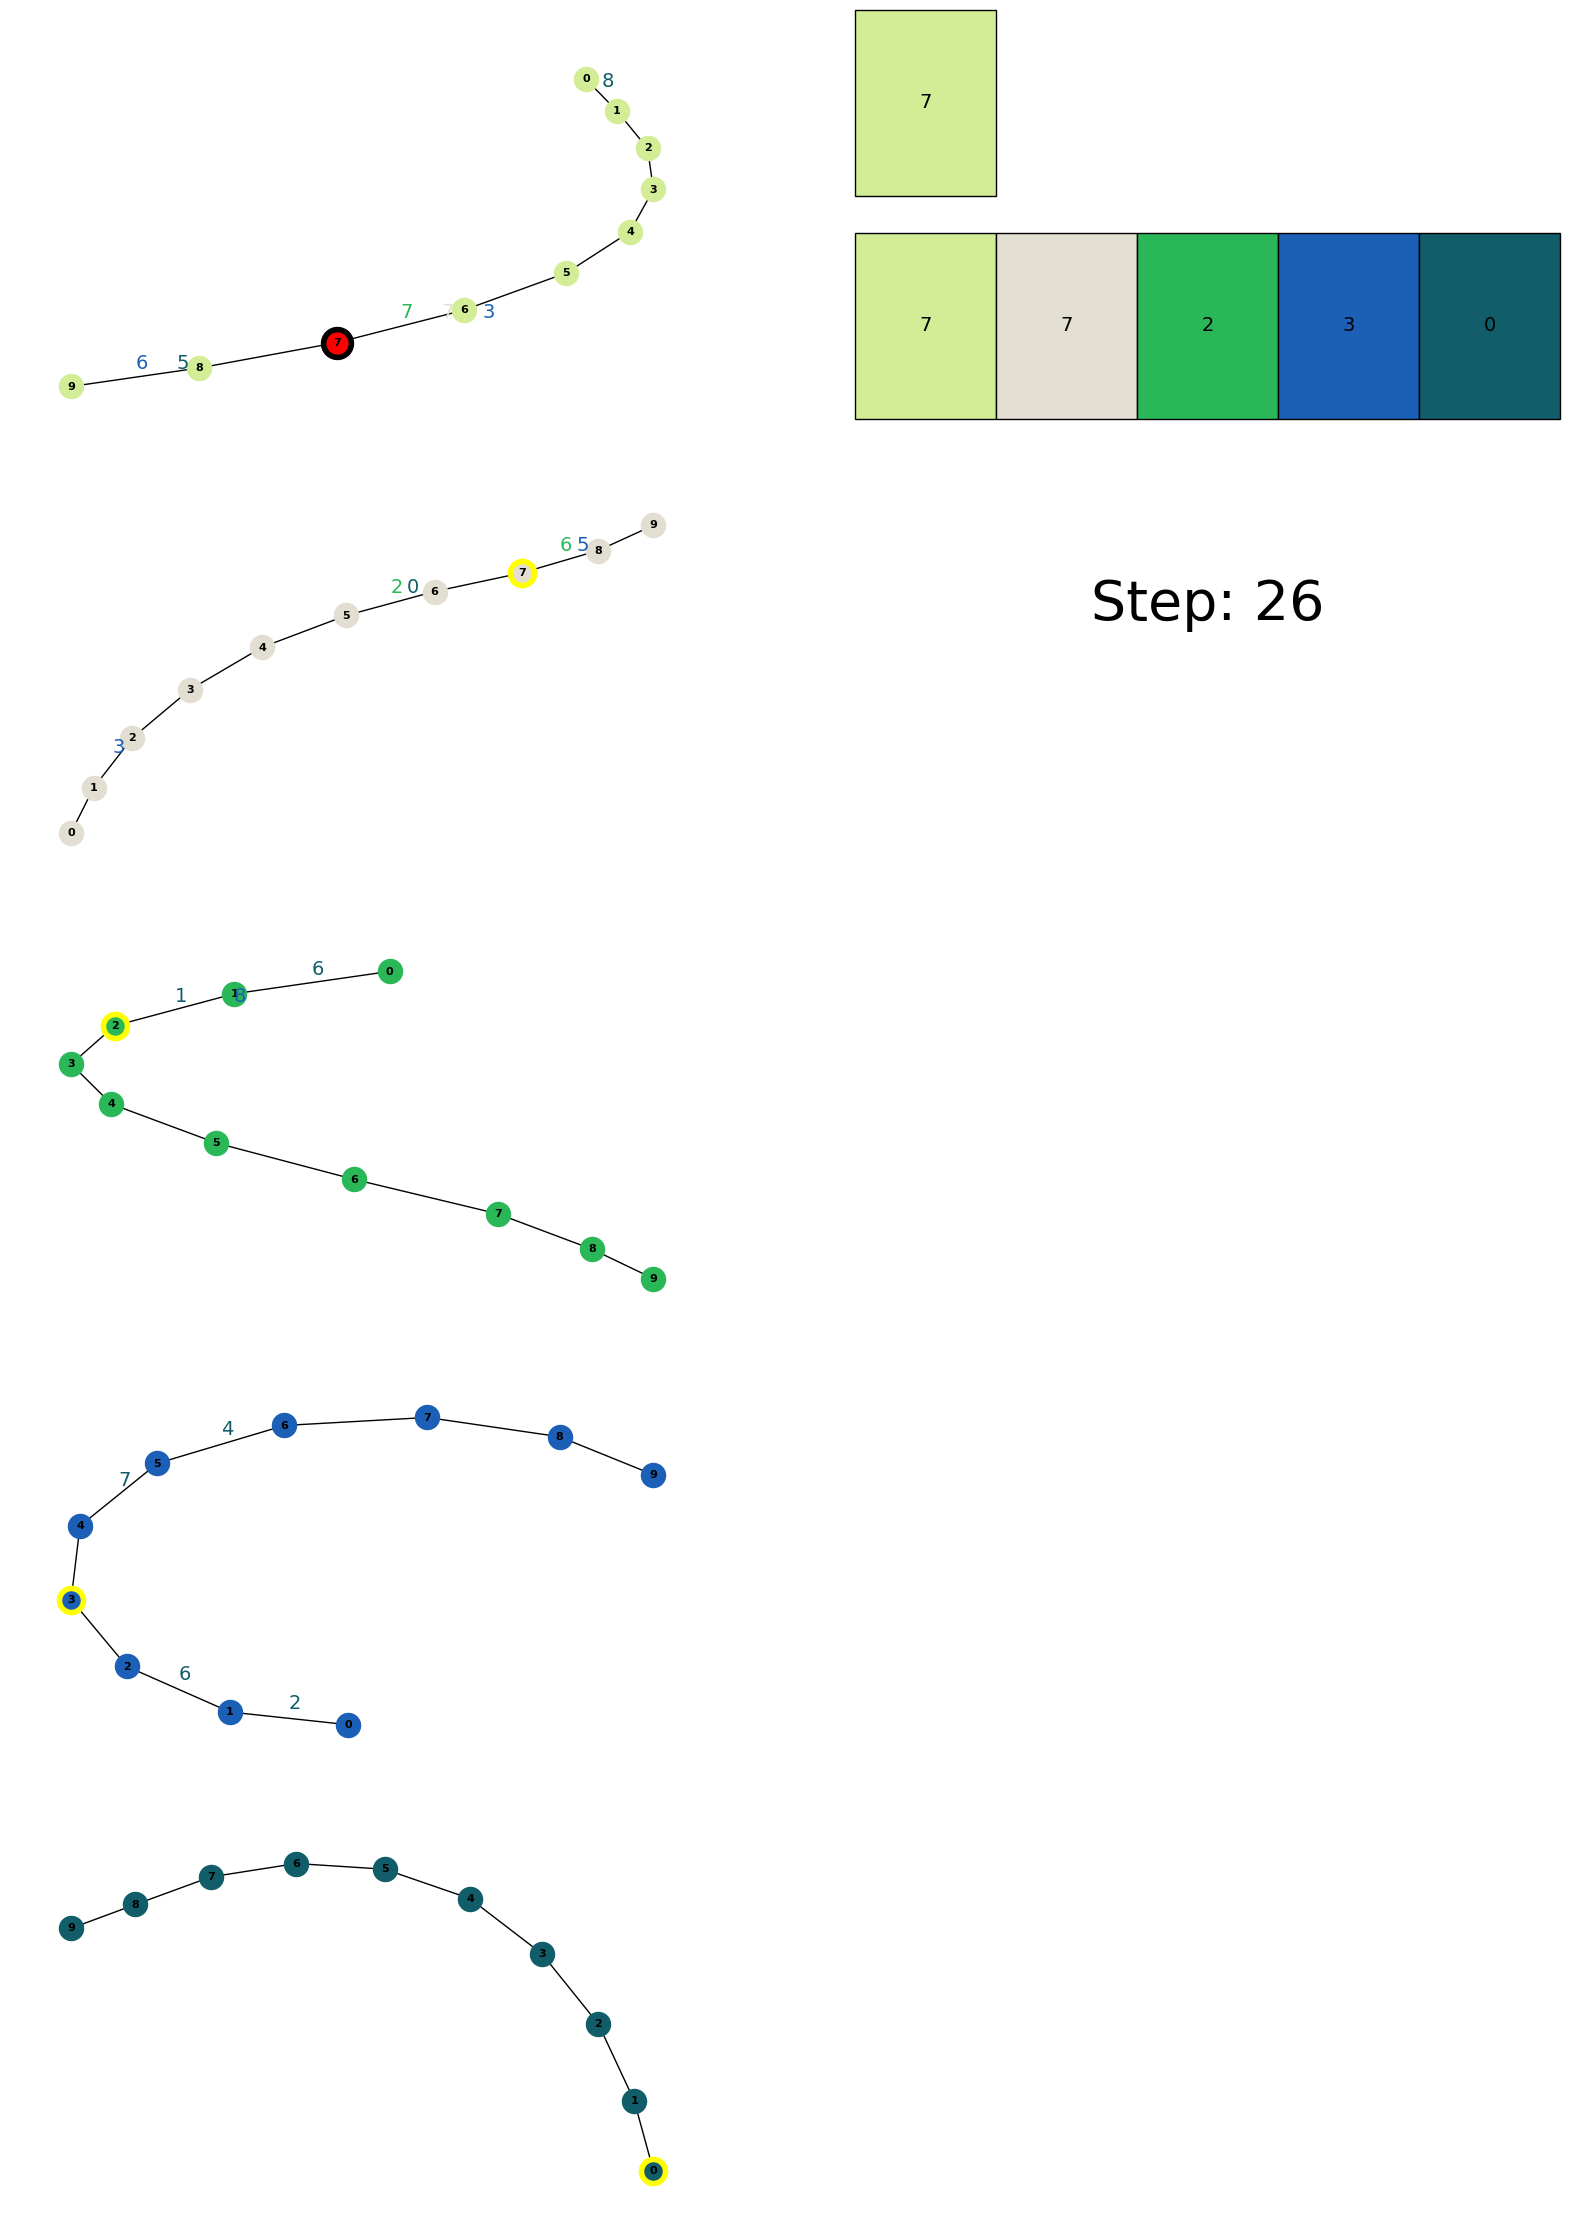

In [253]:
import visualize_search as vs
import importlib

importlib.reload(vs)

visualization = vs.Visualize_search(chains, full_path, sample['input'])
visualization.animate("test_visualization")